In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from pathlib import Path

plt.style.use("ggplot")

In [31]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
DATA = Path("../data/processed")

df = pd.read_csv(DATA / "ethiopia_fi_enriched2.csv")

In [33]:
access = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "ACC_OWNERSHIP")
].copy()

access

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014.0
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017.0
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021.0
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021.0
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021.0
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024.0


In [34]:
access["observation_date"] = pd.to_datetime(access["observation_date"])

access["year"] = access["observation_date"].dt.year

access

X = access[["year"]]

y = access["value_numeric"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5646
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [35]:
future = pd.DataFrame({
    "year":[2025,2026,2027]
})

future["forecast"] = model.predict(future)

future

,year,forecast
0,2025,55.684211
1,2026,58.500000
2,2027,61.315789


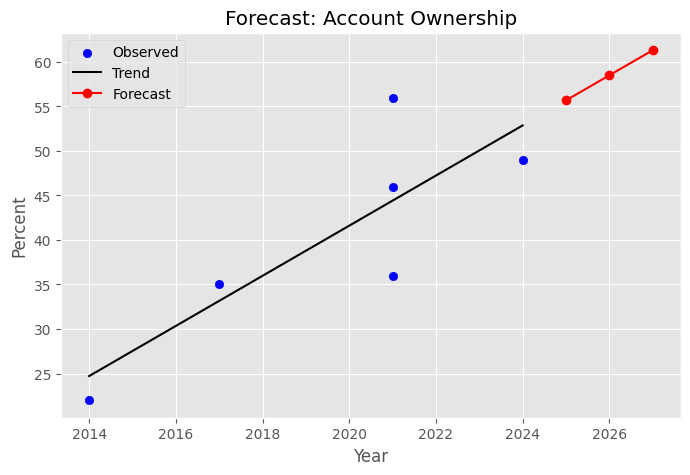

In [36]:
#Plot Access Forecast
plt.figure(figsize=(8,5))

plt.scatter(
    access["year"],
    access["value_numeric"],
    color="blue",
    label="Observed"
)

plt.plot(
    access["year"],
    model.predict(X),
    color="black",
    label="Trend"
)

plt.plot(
    future["year"],
    future["forecast"],
    marker="o",
    color="red",
    label="Forecast"
)

plt.title("Forecast: Account Ownership")

plt.xlabel("Year")

plt.ylabel("Percent")

plt.legend()

plt.show()

In [37]:
#Forecast Digital Payment Usage
usage = df[
    (df["record_type"]=="observation") &
    (df["indicator_code"]=="USG_DIGITAL_PAYMENT")
].copy()

usage["observation_date"] = pd.to_datetime(
    usage["observation_date"]
)

usage["year"] = usage["observation_date"].dt.year

In [38]:
print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

print("\nX2 dtypes:")
print(X2.dtypes)

print("\ny2 dtype:")
print(y2.dtype)

print("\nMissing values:")
print(data.isnull().sum())

print("\nInfinite values:")
import numpy as np
print(np.isinf(X2).sum())
print(np.isinf(y2).sum())

print("\nFirst 5 rows:")
print(data.head(10))

X2 shape: (0, 1)
y2 shape: (0,)

X2 dtypes:
year    int32
dtype: object

y2 dtype:
float64

Missing values:
year             0
value_numeric    0
dtype: int64

Infinite values:
year    0
dtype: int64
0

First 5 rows:
Empty DataFrame
Columns: [year, value_numeric]
Index: []


In [ ]:
future_usage = pd.DataFrame({
    "year":[2025,2026,2027]
})

future_usage["forecast"] = usage_model.predict(
    future_usage
)

future_usage

In [ ]:
#Plot Usage Forecast
plt.figure(figsize=(8,5))

plt.scatter(
    usage["year"],
    usage["value_numeric"],
    label="Observed"
)

plt.plot(
    usage["year"],
    usage_model.predict(X2),
    label="Trend"
)

plt.plot(
    future_usage["year"],
    future_usage["forecast"],
    marker="o",
    label="Forecast"
)

plt.title("Forecast: Digital Payment Usage")

plt.xlabel("Year")

plt.ylabel("% Adults")

plt.legend()

plt.show()

In [ ]:
#Create Scenarios
forecast = future.copy()

forecast["base"] = forecast["forecast"]

forecast["optimistic"] = forecast["forecast"] + 3

forecast["pessimistic"] = forecast["forecast"] - 3

forecast

In [ ]:
#Plot Scenarios
plt.figure(figsize=(8,5))

plt.plot(
    forecast["year"],
    forecast["optimistic"],
    marker="o",
    label="Optimistic"
)

plt.plot(
    forecast["year"],
    forecast["base"],
    marker="o",
    label="Base"
)

plt.plot(
    forecast["year"],
    forecast["pessimistic"],
    marker="o",
    label="Pessimistic"
)

plt.legend()

plt.title("Account Ownership Scenarios")

plt.show()

In [ ]:
#Confidence Intervals
forecast["lower"] = forecast["base"] - 2

forecast["upper"] = forecast["base"] + 2

forecast

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    forecast["year"],
    forecast["base"],
    marker="o",
    label="Forecast"
)

plt.fill_between(
    forecast["year"],
    forecast["lower"],
    forecast["upper"],
    alpha=0.3,
    label="Confidence Interval"
)

plt.legend()

plt.title("Forecast with Confidence Interval")

plt.show()

In [ ]:
forecast.to_csv(
    "../models/access_forecast.csv",
    index=False
)

future_usage.to_csv(
    "../models/usage_forecast.csv",
    index=False
)